In [1]:
import numpy as np 
import pandas as pd
from matplotlib import pyplot as plt 

In [2]:
szp_time = np.loadtxt('szp_time.txt').reshape(-1,5)
edt_time = np.loadtxt('time.txt').reshape(-1,5) 
szp_avg_time = np.mean(szp_time, axis=1) 
edt_avg_time = np.mean(edt_time, axis=1)
edt_speedup = edt_avg_time[0]/edt_avg_time
szp_speedup = szp_avg_time[0]/szp_avg_time
threads = [1,2,4,8,16,32,64]
edt_efficiency = edt_speedup/threads
szp_efficiency = szp_speedup/threads

Text(0.5, 0, 'Number of Threads')

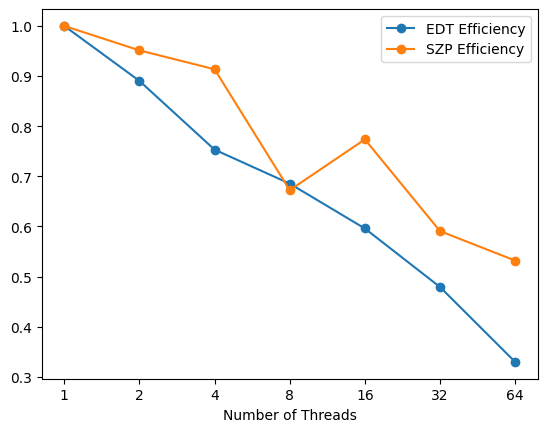

In [3]:
plt.plot(threads, edt_efficiency, label='EDT Efficiency', marker='o')
plt.plot(threads, szp_efficiency, label='SZP Efficiency', marker='o')
plt.legend()
plt.xscale('log', base=2)
plt.xticks(threads, threads)
plt.xlabel('Number of Threads')

In [4]:
def extract_breakdown(file):
    with open(file, 'r') as f:
        lines = f.readlines()
    data = {}
    data ={}
    data['first_boundary'] = []
    data['first_edt'] = []
    data['first_sign'] = []
    data['second_boundary'] = []
    data['second_edt'] = []
    data['compensation'] = []
    for line in lines:
        if "::first boundary time time = " in line:
            data['first_boundary'].append(float(line.split('=')[1].strip()[:-1]))
        elif "::first edt time time = " in line:
            data['first_edt'].append(float(line.split('=')[1].strip()[:-1]))
        elif "::first sign time =" in line:
            data['first_sign'].append(float(line.split('=')[1].strip()[:-1]))
        elif "::second boundary time =" in line:
            data['second_boundary'].append(float(line.split('=')[1].strip()[:-1]))
        elif "::second edt time =" in line:
            data['second_edt'].append(float(line.split('=')[1].strip()[:-1]))
        elif "::compensation time =" in line:
            data['compensation'].append(float(line.split('=')[1].strip()[:-1]))
    return data


In [40]:
def get_data_from_logs(logfile):
    breakdown = extract_breakdown(logfile) 
    for key in breakdown:
        # print(f"{key}: {len(breakdown[key])}")
        breakdown[key] = np.array(breakdown[key]).reshape(-1,5)
        
    breakdown_avg = {}
    for key in breakdown:
        breakdown_avg[key] = np.mean(breakdown[key], axis=1)
    total_avg = np.zeros(len(threads))
    total_avg_percent = np.zeros((len(threads), len(breakdown_avg)))
    for i in range(len(threads)):
        for key in breakdown_avg:
            total_avg[i] += breakdown_avg[key][i]

    for i in range(len(threads)):
        for j, key in enumerate(breakdown_avg):
            total_avg_percent[i, j] = breakdown_avg[key][i] / total_avg[i] * 100
    
    return breakdown_avg, total_avg, total_avg_percent 

Efficiency before: [1.         0.86034387 0.77304469 0.69355313 0.66215359 0.5821081
 0.4473693 ]
Efficiency after: [1.         0.94282957 0.90858525 0.8721318  0.84538499 0.73144146
 0.50940233]


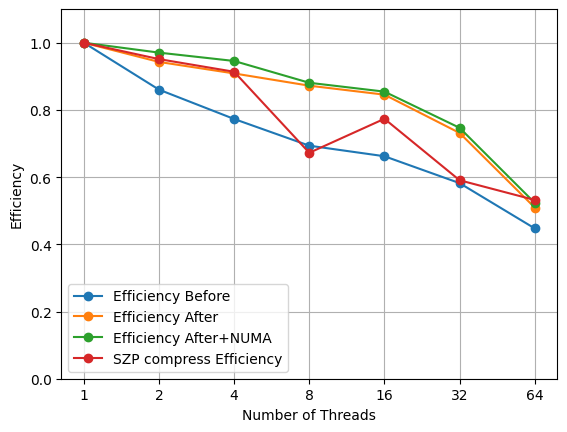

In [64]:
breakdown_avg_before, total_avg_before, total_avg_percent_before  = get_data_from_logs('breakdown_before.log')
breakdown_avg_after, total_avg_after, total_avg_percent_after  = get_data_from_logs('breakdown.log')
breakdown_avg_after_1, total_avg_after_1, total_avg_percent_after_1  = get_data_from_logs('breakdown_seperate.log')

efficiency_before = total_avg_before[0]/(threads*total_avg_before)
efficiency_after = total_avg_after[0]/(threads*total_avg_after)
efficiency_after_1 = total_avg_after_1[0]/(threads*total_avg_after_1)
print("Efficiency before:", efficiency_before)
print("Efficiency after:", efficiency_after)
plt.plot(threads, efficiency_before, label='Efficiency Before', marker='o')
plt.plot(threads, efficiency_after, label='Efficiency After', marker='o')
plt.plot(threads, efficiency_after_1, label='Efficiency After+NUMA', marker='o')

plt.plot(threads, szp_efficiency, label='SZP compress Efficiency', marker='o')

plt.legend()
plt.xscale('log', base=2)
plt.xticks(threads, threads)
plt.xlabel('Number of Threads')
plt.ylabel('Efficiency')
plt.ylim(0,1.1)
plt.grid()


In [20]:
breakdown = extract_breakdown('breakdown_1.log') 
for key in breakdown:
    # print(f"{key}: {len(breakdown[key])}")
    breakdown[key] = np.array(breakdown[key]).reshape(-1,5)
    
breakdown_avg = {}
for key in breakdown:
    breakdown_avg[key] = np.mean(breakdown[key], axis=1)
total_avg = np.zeros(len(threads))
total_avg_percent = np.zeros((len(threads), len(breakdown_avg)))
for i in range(len(threads)):
    for key in breakdown_avg:
        total_avg[i] += breakdown_avg[key][i]

for i in range(len(threads)):
    for j, key in enumerate(breakdown_avg):
        total_avg_percent[i, j] = breakdown_avg[key][i] / total_avg[i] * 100


5.535603680000001

In [19]:
breakdown_avg['first_edt']

array([2.276752  , 1.416496  , 0.7632376 , 0.4301316 , 0.2376596 ,
       0.1400616 , 0.08318012])

In [14]:
breakdown_avg['first_edt']

array([2.341198 , 1.19964  , 0.6130654, 0.3230332, 0.1659734, 0.0909495,
       0.0656881])

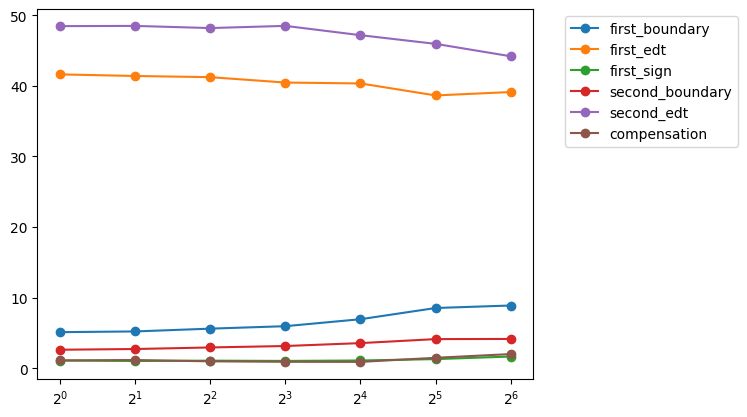

In [6]:
labels = list(breakdown_avg.keys()) 
for i in range(len(labels)): 
    plt.plot(threads, total_avg_percent[:, i], label=labels[i], marker='o')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xscale('log', base=2)



In [7]:
# for each key, calculate the speedup and efficiency
breakdown_speedup = {}
breakdown_efficiency = {}
total_avg = {}
for key in breakdown_avg:
    breakdown_speedup[key] = breakdown_avg[key][0]/breakdown_avg[key]
    breakdown_efficiency[key] = breakdown_speedup[key]/threads

Text(0.5, 1.0, 'Breakdown Efficiency')

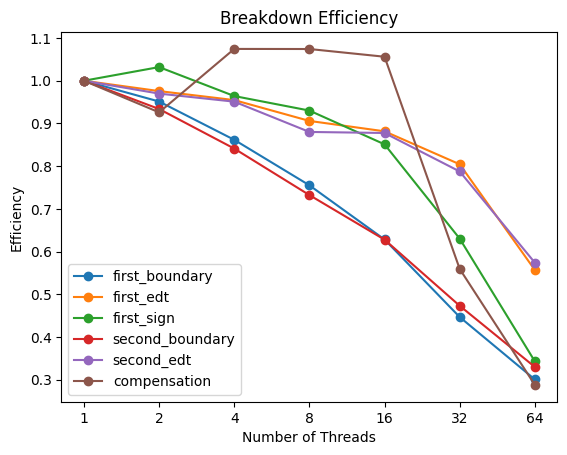

In [8]:
# plot breakdown efficiency 
for key in breakdown_efficiency:
    plt.plot(threads, breakdown_efficiency[key], label=key, marker='o')
plt.legend()
plt.xscale('log', base=2)
plt.xticks(threads, threads)
plt.xlabel('Number of Threads')
plt.ylabel('Efficiency')
plt.title('Breakdown Efficiency')
# plt.ylim(0,1)               

Text(0.5, 1.0, 'Breakdown Speedup')

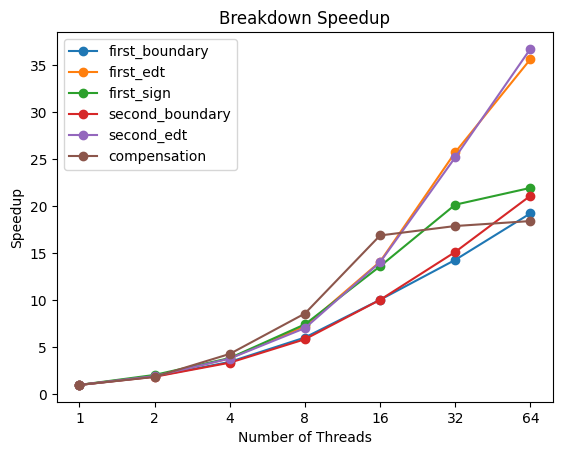

In [9]:
# plot breakdown efficiency 
for key in breakdown_speedup:
    plt.plot(threads, breakdown_speedup[key], label=key, marker='o')
plt.legend()
plt.xscale('log', base=2)
plt.xticks(threads, threads)
plt.xlabel('Number of Threads')
plt.ylabel('Speedup')
plt.title('Breakdown Speedup')
# plt.ylim(0,1)     